In [1]:
!pip install lightgbm -q

In [2]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, log_loss

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from lightgbm import LGBMClassifier

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

In [10]:
import pandas as pd

train = pd.read_csv(
    "/content/drive/MyDrive/dataset_A_training.csv"
)

test = pd.read_csv(
    "/content/drive/MyDrive/dataset_A_testing.csv"
)

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

train.head()

Training shape: (4756, 31)
Testing shape: (4749, 30)


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


In [11]:
print(train.info())

print("\nTraining columns:")
print(train.columns.tolist())

print("\nTesting columns:")
print(test.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   flu_concern                  4744 non-null   float64
 2   flu_knowledge                4733 non-null   float64
 3   behavioral_antiviral_meds    4742 non-null   float64
 4   behavioral_avoidance         4724 non-null   float64
 5   behavioral_face_mask         4753 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4747 non-null   float64
 9   behavioral_touch_face        4737 non-null   float64
 10  doctor_recc_seasonal         4435 non-null   float64
 11  chronic_med_condition        4568 non-null   float64
 12  child_under_6_months         4604 non-null   float64
 13  health_worker     

In [13]:
print("Training duplicates:", train.duplicated().sum())
print("Testing duplicates:", test.duplicated().sum())

Training duplicates: 0
Testing duplicates: 0


In [14]:
missing_values = train.isnull().mean().sort_values(
    ascending=False
)

print(missing_values.head(15))

employment_sector              0.486543
health_insurance               0.404752
income_poverty                 0.166106
rent_or_own                    0.080109
doctor_recc_seasonal           0.067494
education                      0.056770
employment_status              0.056560
marital_status                 0.055719
chronic_med_condition          0.039529
child_under_6_months           0.031960
health_worker                  0.031329
opinion_seas_risk              0.021447
opinion_seas_sick_from_vacc    0.021236
opinion_seas_vacc_effective    0.019765
household_children             0.009251
dtype: float64


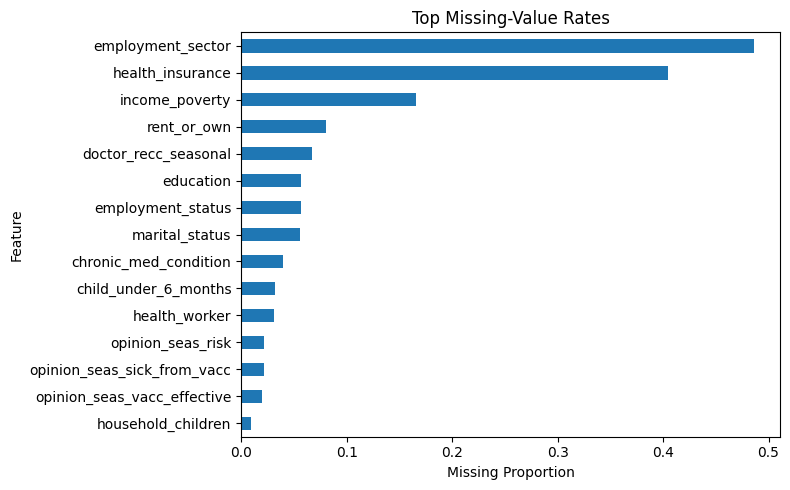

In [15]:
missing_values.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top Missing-Value Rates")
plt.xlabel("Missing Proportion")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [16]:
TARGET = "seasonal_vaccine"
ID_COL = "respondent_id"

print(train[TARGET].value_counts())

print("\nTarget percentages:")
print(
    train[TARGET]
    .value_counts(normalize=True)
    .round(3)
)

seasonal_vaccine
1    2551
0    2205
Name: count, dtype: int64

Target percentages:
seasonal_vaccine
1    0.536
0    0.464
Name: proportion, dtype: float64


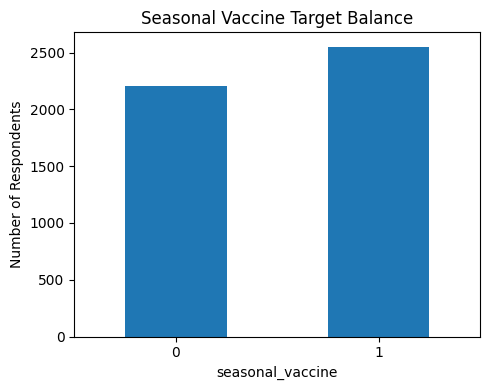

In [17]:
train[TARGET].value_counts().sort_index().plot(
    kind="bar",
    figsize=(5, 4)
)

plt.title("Seasonal Vaccine Target Balance")
plt.xlabel("seasonal_vaccine")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
important_features = [
    "doctor_recc_seasonal",
    "opinion_seas_vacc_effective",
    "opinion_seas_risk",
    "health_worker",
    "flu_concern",
    "age_group"
]

for feature in important_features:

    if feature in train.columns:

        result = (
            train.groupby(feature)[TARGET]
            .mean()
            .sort_values()
        )

        print("\nFeature:", feature)
        print(result.round(3))


Feature: doctor_recc_seasonal
doctor_recc_seasonal
0.0    0.410
1.0    0.775
Name: seasonal_vaccine, dtype: float64

Feature: opinion_seas_vacc_effective
opinion_seas_vacc_effective
2.0    0.168
1.0    0.244
3.0    0.356
4.0    0.446
5.0    0.749
Name: seasonal_vaccine, dtype: float64

Feature: opinion_seas_risk
opinion_seas_risk
1.0    0.244
2.0    0.435
3.0    0.675
4.0    0.713
5.0    0.786
Name: seasonal_vaccine, dtype: float64

Feature: health_worker
health_worker
0.0    0.511
1.0    0.727
Name: seasonal_vaccine, dtype: float64

Feature: flu_concern
flu_concern
0.0    0.358
1.0    0.481
2.0    0.596
3.0    0.616
Name: seasonal_vaccine, dtype: float64

Feature: age_group
age_group
18 - 34 Years    0.349
35 - 44 Years    0.426
45 - 54 Years    0.497
55 - 64 Years    0.609
65+ Years        0.725
Name: seasonal_vaccine, dtype: float64


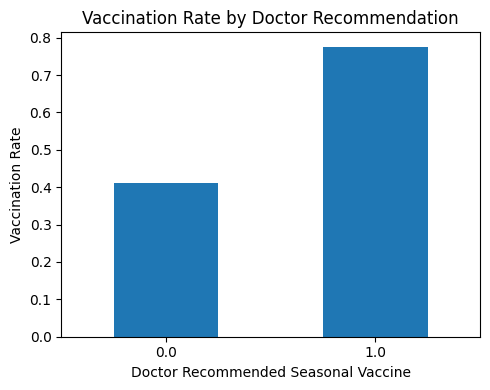

In [19]:
(
    train.groupby("doctor_recc_seasonal")[TARGET]
    .mean()
    .plot(
        kind="bar",
        figsize=(5, 4)
    )
)

plt.title("Vaccination Rate by Doctor Recommendation")
plt.xlabel("Doctor Recommended Seasonal Vaccine")
plt.ylabel("Vaccination Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

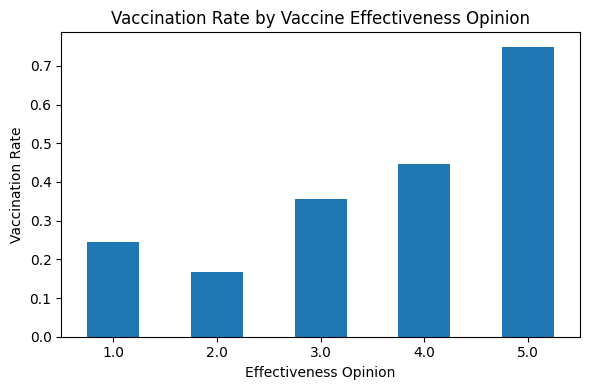

In [20]:
(
    train.groupby("opinion_seas_vacc_effective")[TARGET]
    .mean()
    .plot(
        kind="bar",
        figsize=(6, 4)
    )
)

plt.title("Vaccination Rate by Vaccine Effectiveness Opinion")
plt.xlabel("Effectiveness Opinion")
plt.ylabel("Vaccination Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
X = train.drop(
    columns=[
        TARGET,
        ID_COL
    ]
)

y = train[TARGET].astype(int)

X_test = test.drop(
    columns=[
        ID_COL
    ]
)

print("Training features shape:", X.shape)
print("Testing features shape:", X_test.shape)

Training features shape: (4756, 29)
Testing features shape: (4749, 29)


In [22]:
categorical_columns = (
    X.select_dtypes(include="object")
    .columns
    .tolist()
)

numerical_columns = [
    column
    for column in X.columns
    if column not in categorical_columns
]

print("Categorical columns:", len(categorical_columns))
print("Numerical columns:", len(numerical_columns))

print("\nCategorical features:")
print(categorical_columns)

Categorical columns: 10
Numerical columns: 19

Categorical features:
['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [23]:
def make_preprocessor():

    return ColumnTransformer([
        (
            "numerical",
            SimpleImputer(
                strategy="median"
            ),
            numerical_columns
        ),

        (
            "categorical",
            Pipeline([
                (
                    "fill_missing",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),

                (
                    "one_hot_encoding",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_columns
        )
    ])

In [24]:
def make_pipeline(model):

    return Pipeline([
        (
            "preprocessing",
            make_preprocessor()
        ),

        (
            "model",
            model
        )
    ])

In [25]:
models = {

    "logistic_regression": make_pipeline(
        LogisticRegression(
            max_iter=1200,
            C=1.0,
            solver="liblinear",
            random_state=42
        )
    ),

    "random_forest": make_pipeline(
        RandomForestClassifier(
            n_estimators=180,
            min_samples_leaf=4,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        )
    ),

    "extra_trees": make_pipeline(
        ExtraTreesClassifier(
            n_estimators=180,
            min_samples_leaf=4,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        )
    ),

    "hist_gradient_boosting": make_pipeline(
        HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=120,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42
        )
    ),

    "lightgbm": make_pipeline(
        LGBMClassifier(
            n_estimators=180,
            learning_rate=0.03,
            num_leaves=23,
            min_child_samples=22,
            reg_lambda=2.0,
            verbosity=-1,
            n_jobs=-1,
            random_state=42
        )
    )
}

In [26]:
cross_validation = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [27]:
def choose_threshold(
    actual_values,
    predicted_probabilities
):

    thresholds = np.linspace(
        0.40,
        0.60,
        81
    )

    accuracy_scores = [
        accuracy_score(
            actual_values,
            predicted_probabilities >= threshold
        )

        for threshold in thresholds
    ]

    best_position = int(
        np.argmax(
            accuracy_scores
        )
    )

    return (
        float(
            thresholds[best_position]
        ),

        float(
            accuracy_scores[best_position]
        )
    )

In [28]:
model_results = []
validation_probabilities = {}

for model_name, model in models.items():

    print("Training:", model_name)

    predicted_probabilities = cross_val_predict(
        estimator=model,
        X=X,
        y=y,
        cv=cross_validation,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    threshold, accuracy = choose_threshold(
        actual_values=y,
        predicted_probabilities=predicted_probabilities
    )

    predictions = (
        predicted_probabilities >= threshold
    ).astype(int)

    model_results.append({

        "model": model_name,

        "accuracy": accuracy,

        "roc_auc": roc_auc_score(
            y,
            predicted_probabilities
        ),

        "f1_score": f1_score(
            y,
            predictions
        ),

        "log_loss": log_loss(
            y,
            predicted_probabilities
        ),

        "threshold": threshold
    })

    validation_probabilities[
        model_name
    ] = predicted_probabilities

Training: logistic_regression
Training: random_forest
Training: extra_trees
Training: hist_gradient_boosting
Training: lightgbm


In [29]:
model_summary = pd.DataFrame(
    model_results
)

model_summary = model_summary.sort_values(
    by=[
        "accuracy",
        "roc_auc"
    ],
    ascending=False
).reset_index(drop=True)

model_summary.insert(
    0,
    "rank",
    np.arange(
        1,
        len(model_summary) + 1
    )
)

model_summary

,rank,model,accuracy,roc_auc,f1_score,log_loss,threshold
0,1,logistic_regression,0.777754,0.844600,0.794877,0.490613,0.5000
1,2,hist_gradient_boosting,0.775652,0.848783,0.798337,0.482001,0.4700
2,3,lightgbm,0.775652,0.846172,0.798489,0.485820,0.4675
3,4,random_forest,0.771236,0.844638,0.787997,0.502151,0.4850
4,5,extra_trees,0.769344,0.841009,0.785951,0.506728,0.4825


In [30]:
model_summary = pd.DataFrame(
    model_results
)

model_summary = model_summary.sort_values(
    by=[
        "accuracy",
        "roc_auc"
    ],
    ascending=False
).reset_index(drop=True)

model_summary.insert(
    0,
    "rank",
    np.arange(
        1,
        len(model_summary) + 1
    )
)

model_summary

,rank,model,accuracy,roc_auc,f1_score,log_loss,threshold
0,1,logistic_regression,0.777754,0.844600,0.794877,0.490613,0.5000
1,2,hist_gradient_boosting,0.775652,0.848783,0.798337,0.482001,0.4700
2,3,lightgbm,0.775652,0.846172,0.798489,0.485820,0.4675
3,4,random_forest,0.771236,0.844638,0.787997,0.502151,0.4850
4,5,extra_trees,0.769344,0.841009,0.785951,0.506728,0.4825


In [32]:
model_summary.to_csv(
    "/content/drive/MyDrive/model_summary_5_models.csv",
    index=False
)

print("Saved model summary.")

Saved model summary.


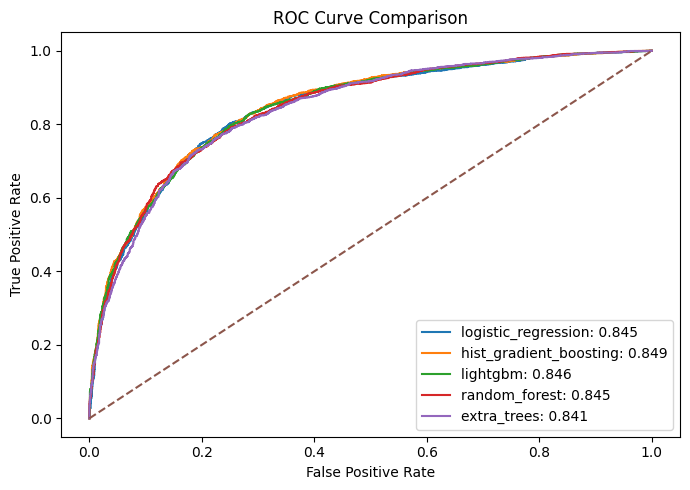

In [33]:
plt.figure(
    figsize=(7, 5)
)

for model_name in model_summary["model"]:

    probabilities = validation_probabilities[
        model_name
    ]

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y,
        probabilities
    )

    auc_score = roc_auc_score(
        y,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name}: {auc_score:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
best_model_name = model_summary.iloc[0]["model"]

best_threshold = model_summary.iloc[0][
    "threshold"
]

best_validation_probabilities = (
    validation_probabilities[
        best_model_name
    ]
)

best_validation_predictions = (
    best_validation_probabilities
    >= best_threshold
).astype(int)

print("Best model:", best_model_name)

print(
    classification_report(
        y,
        best_validation_predictions
    )
)

Best model: logistic_regression
              precision    recall  f1-score   support

           0       0.77      0.75      0.76      2205
           1       0.79      0.80      0.79      2551

    accuracy                           0.78      4756
   macro avg       0.78      0.78      0.78      4756
weighted avg       0.78      0.78      0.78      4756



In [35]:
lightgbm_pipeline = make_pipeline(
    LGBMClassifier(
        verbosity=-1,
        n_jobs=-1,
        random_state=42
    )
)

lightgbm_parameters = {

    "model__n_estimators": [
        120,
        180
    ],

    "model__learning_rate": [
        0.03,
        0.05
    ],

    "model__num_leaves": [
        15,
        23
    ]
}

lightgbm_grid_search = GridSearchCV(
    estimator=lightgbm_pipeline,
    param_grid=lightgbm_parameters,
    scoring="roc_auc",
    cv=3,
    n_jobs=1,
    verbose=1
)

lightgbm_grid_search.fit(
    X,
    y
)

print(
    "Best LightGBM parameters:"
)

print(
    lightgbm_grid_search.best_params_
)

print(
    "\nBest LightGBM ROC-AUC:",
    round(
        lightgbm_grid_search.best_score_,
        4
    )
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best LightGBM parameters:
{'model__learning_rate': 0.03, 'model__n_estimators': 180, 'model__num_leaves': 15}

Best LightGBM ROC-AUC: 0.852


In [36]:
models["lightgbm"] = (
    lightgbm_grid_search.best_estimator_
)

print(
    "Tuned LightGBM model saved."
)

Tuned LightGBM model saved.


In [37]:
test_prediction_store = {}

for model_name, model in models.items():

    print("Final training:", model_name)

    final_model = clone(model)

    final_model.fit(
        X,
        y
    )

    test_probabilities = (
        final_model.predict_proba(
            X_test
        )[:, 1]
    )

    threshold = model_summary.loc[
        model_summary["model"] == model_name,
        "threshold"
    ].iloc[0]

    test_predictions = (
        test_probabilities >= threshold
    ).astype(int)

    test_prediction_store[
        model_name
    ] = {

        "model": final_model,

        "probabilities": test_probabilities,

        "predictions": test_predictions
    }

Final training: logistic_regression
Final training: random_forest
Final training: extra_trees
Final training: hist_gradient_boosting
Final training: lightgbm


In [38]:
output_folder = (
    "/content/drive/MyDrive/Hackthon/submissions"
)

os.makedirs(
    output_folder,
    exist_ok=True
)

submission_files = []

for row in model_summary.itertuples(
    index=False
):

    model_name = row.model

    submission = pd.DataFrame({

        ID_COL:
        test[ID_COL],

        TARGET:
        test_prediction_store[
            model_name
        ]["predictions"]
    })

    filename = (
        f"submission_{row.rank}_{model_name}.csv"
    )

    full_path = os.path.join(
        output_folder,
        filename
    )

    submission.to_csv(
        full_path,
        index=False
    )

    submission_files.append(
        full_path
    )

    print(
        "Created:",
        full_path
    )

Created: /content/drive/MyDrive/Hackthon/submissions/submission_1_logistic_regression.csv
Created: /content/drive/MyDrive/Hackthon/submissions/submission_2_hist_gradient_boosting.csv
Created: /content/drive/MyDrive/Hackthon/submissions/submission_3_lightgbm.csv
Created: /content/drive/MyDrive/Hackthon/submissions/submission_4_random_forest.csv
Created: /content/drive/MyDrive/Hackthon/submissions/submission_5_extra_trees.csv


In [39]:
probability_files = []

for row in model_summary.itertuples(
    index=False
):

    model_name = row.model

    probability_file = pd.DataFrame({

        ID_COL:
        test[ID_COL],

        f"{TARGET}_probability":
        test_prediction_store[
            model_name
        ]["probabilities"]
    })

    filename = (
        f"probability_{row.rank}_{model_name}.csv"
    )

    full_path = os.path.join(
        output_folder,
        filename
    )

    probability_file.to_csv(
        full_path,
        index=False
    )

    probability_files.append(
        full_path
    )

    print(
        "Created:",
        full_path
    )

Created: /content/drive/MyDrive/Hackthon/submissions/probability_1_logistic_regression.csv
Created: /content/drive/MyDrive/Hackthon/submissions/probability_2_hist_gradient_boosting.csv
Created: /content/drive/MyDrive/Hackthon/submissions/probability_3_lightgbm.csv
Created: /content/drive/MyDrive/Hackthon/submissions/probability_4_random_forest.csv
Created: /content/drive/MyDrive/Hackthon/submissions/probability_5_extra_trees.csv


In [40]:
best_ranked_model = model_summary.iloc[0][
    "model"
]

best_submission = pd.DataFrame({

    ID_COL:
    test[ID_COL],

    TARGET:
    test_prediction_store[
        best_ranked_model
    ]["predictions"]
})

print(
    "Best ranked model:",
    best_ranked_model
)

best_submission.head()

Best ranked model: logistic_regression


,respondent_id,seasonal_vaccine
0,4757,0
1,4758,1
2,4759,1
3,4760,1
4,4761,0


In [41]:
trained_lightgbm_pipeline = (
    test_prediction_store[
        "lightgbm"
    ]["model"]
)

preprocessor = (
    trained_lightgbm_pipeline
    .named_steps[
        "preprocessing"
    ]
)

lightgbm_model = (
    trained_lightgbm_pipeline
    .named_steps[
        "model"
    ]
)

feature_names = (
    preprocessor
    .get_feature_names_out()
)

feature_importance = pd.Series(

    lightgbm_model
    .feature_importances_,

    index=feature_names
).sort_values(
    ascending=False
)

feature_importance.head(15)

,0
numerical__opinion_seas_vacc_effective,244
numerical__opinion_seas_risk,242
numerical__doctor_recc_seasonal,146
numerical__opinion_seas_sick_from_vacc,144
categorical__age_group_65+ Years,142
numerical__health_worker,117
numerical__flu_knowledge,114
categorical__age_group_18 - 34 Years,101
numerical__household_children,87
numerical__household_adults,66


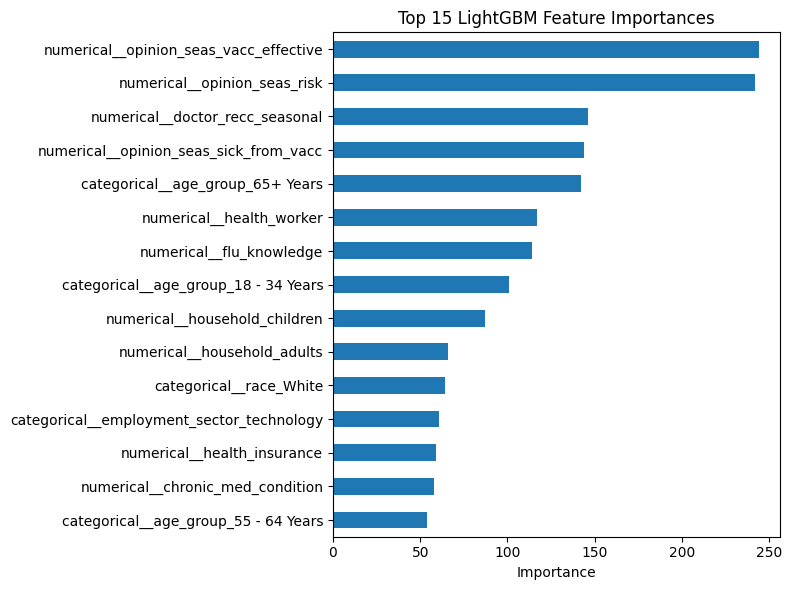

In [42]:
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title(
    "Top 15 LightGBM Feature Importances"
)

plt.xlabel(
    "Importance"
)

plt.tight_layout()
plt.show()

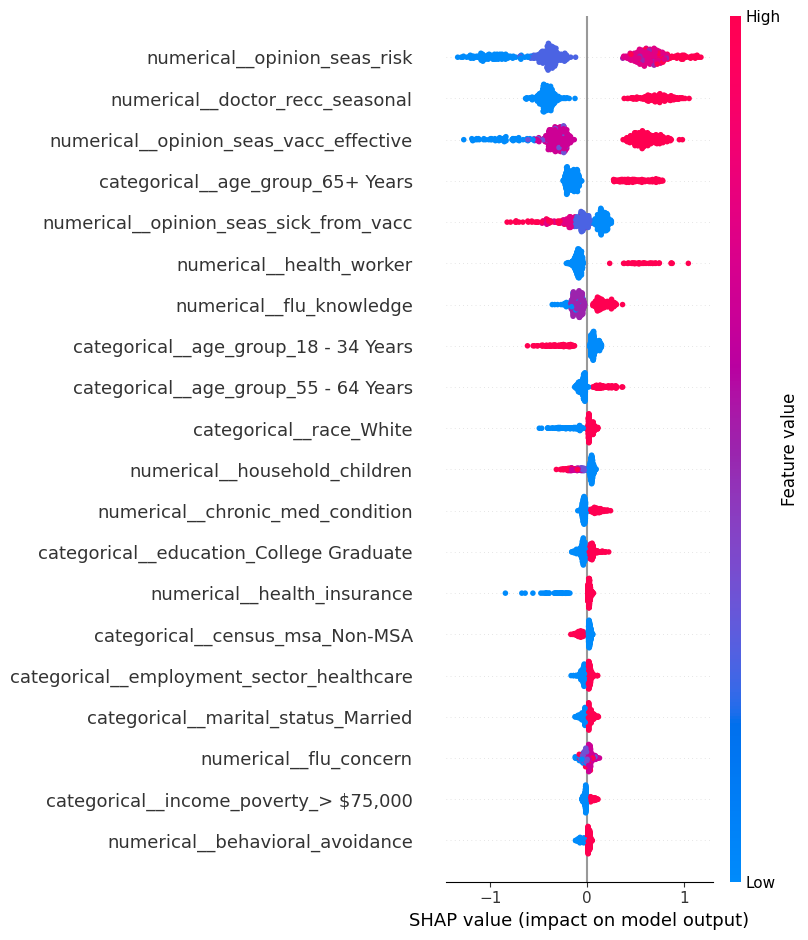

In [43]:
import shap

X_sample = X.sample(
    n=min(
        500,
        len(X)
    ),
    random_state=42
)

X_sample_processed = (
    preprocessor.transform(
        X_sample
    )
)

explainer = shap.TreeExplainer(
    lightgbm_model
)

shap_values = explainer.shap_values(
    X_sample_processed
)

if isinstance(
    shap_values,
    list
):

    shap_values = shap_values[1]

shap.summary_plot(
    shap_values,
    X_sample_processed,
    feature_names=feature_names
)

In [44]:
print(
    "Submit the CSV files in this order:"
)

for row in model_summary.itertuples(
    index=False
):

    print(
        f"{row.rank}. "
        f"{row.model} | "
        f"Accuracy: {row.accuracy:.4f} | "
        f"ROC-AUC: {row.roc_auc:.4f} | "
        f"F1: {row.f1_score:.4f}"
    )

Submit the CSV files in this order:
1. logistic_regression | Accuracy: 0.7778 | ROC-AUC: 0.8446 | F1: 0.7949
2. hist_gradient_boosting | Accuracy: 0.7757 | ROC-AUC: 0.8488 | F1: 0.7983
3. lightgbm | Accuracy: 0.7757 | ROC-AUC: 0.8462 | F1: 0.7985
4. random_forest | Accuracy: 0.7712 | ROC-AUC: 0.8446 | F1: 0.7880
5. extra_trees | Accuracy: 0.7693 | ROC-AUC: 0.8410 | F1: 0.7860
